<a href="https://colab.research.google.com/github/BrunaHer/credit-risk-eda/blob/main/Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Definição do problema**

### **O histórico financeiro impacta a aprovação do crédito?**

> O conjunto de dados *Credit.csv* reúne informações financeiras e socioeconômicas de indivíduos que solicitaram crédito, englobando desde características pessoais até o histórico financeiro e as condições do empréstimo. O objetivo desse dataset é analisar fatores associados ao risco de crédito.



**Gestão de Risco vs. Lucro:** A concessão de crédito é o coração de qualquer instituição financeira. Se a análise provar que clientes com histórico ruim representam um risco real, o banco justifica a criação de regras rigorosas para proteger seu caixa.

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import seaborn as sns

## **2. Compreensão dos dados**

### Importar dataset do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
caminho_df = '/content/drive/MyDrive/data science/Credit.csv'

In [ ]:
df = pd.read_csv(caminho_df)

### Visualização df

In [ ]:
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,'no checking',12,'existing paid',furniture/equipment,1736,<100,4<=X<7,3,'female div/dep/mar',none,...,'real estate',31,none,own,1,'unskilled resident',1,none,yes,good
996,<0,30,'existing paid','used car',3857,<100,1<=X<4,4,'male div/sep',none,...,'life insurance',40,none,own,1,'high qualif/self emp/mgmt',1,yes,yes,good
997,'no checking',12,'existing paid',radio/tv,804,<100,>=7,4,'male single',none,...,car,38,none,own,1,skilled,1,none,yes,good
998,<0,45,'existing paid',radio/tv,1845,<100,1<=X<4,4,'male single',none,...,'no known property',23,none,'for free',1,skilled,1,yes,yes,bad


As dimensões do dataframe são: 1000 linhas e 21 colunas

In [ ]:
df.head(10)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,'critical/other existing credit',radio/tv,1169,'no known savings',>=7,4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,'existing paid',radio/tv,5951,<100,1<=X<4,2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,<100,4<=X<7,2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,<0,42,'existing paid',furniture/equipment,7882,<100,4<=X<7,2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,<0,24,'delayed previously','new car',4870,<100,1<=X<4,3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad
5,'no checking',36,'existing paid',education,9055,'no known savings',1<=X<4,2,'male single',none,...,'no known property',35,none,'for free',1,'unskilled resident',2,yes,yes,good
6,'no checking',24,'existing paid',furniture/equipment,2835,500<=X<1000,>=7,3,'male single',none,...,'life insurance',53,none,own,1,skilled,1,none,yes,good
7,0<=X<200,36,'existing paid','used car',6948,<100,1<=X<4,2,'male single',none,...,car,35,none,rent,1,'high qualif/self emp/mgmt',1,yes,yes,good
8,'no checking',12,'existing paid',radio/tv,3059,>=1000,4<=X<7,2,'male div/sep',none,...,'real estate',61,none,own,1,'unskilled resident',1,none,yes,good
9,0<=X<200,30,'critical/other existing credit','new car',5234,<100,unemployed,4,'male mar/wid',none,...,car,28,none,own,2,'high qualif/self emp/mgmt',1,none,yes,bad


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

In [ ]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [ ]:
# Validando os nulos por ordem crescente
df.isnull().sum().sort_values(ascending=True)

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Não foi encontrado nenhum valor duplicado ou nulo

In [ ]:
df.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

##  **3. Limpeza e preparação**
Seleção das colunas que são importantes e que serão utilizadas para responder a pergunta orientadora

### Escolha de colunas do dataset

In [ ]:
# Removendo as colunas que não são utilizáveis
colunas_para_remover = [
    'own_telephone',     # Ter telefone não define histórico financeiro
    'foreign_worker',    # Ser estrangeiro foge do escopo da pergunta
    'residence_since',   # Tempo no endereço atual
    'num_dependents',    # Número de dependentes
    'other_parties'      # Fiadores
]

# Removendo as colunas do dataframe (o errors='ignore' evita erro se rodar a célula duas vezes)
df.drop(columns=colunas_para_remover, inplace=True, errors='ignore')



In [ ]:
# Verificando as colunas que sobraram para confirmar a limpeza
print(f"Número de colunas após a limpeza: {df.shape[1]}")
print("Colunas restantes:", df.columns.tolist())

Número de colunas após a limpeza: 16
Colunas restantes: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'class']


### Tradução das colunas

In [ ]:
# Renomeando várias colunas de uma vez só
df.rename(columns={
    'checking_status': 'status_conta',
    'duration': 'duracao',
    'credit_history': 'historico_credito',
    'purpose': 'finalidade',
    'credit_amount' : 'valor_emprestimo',
    'savings_status' : 'status_poupanca',
    'employment': 'tempo_emprego',
    'installment_commitment' : 'comprometimento_renda',
    'personal_status': 'perfil_pessoal',
    'property_magnitude': 'quantidade_bens',
    'age': 'idade_anos',
    'other_payment_plans': 'outros_planos_pagamento',
    'housing': 'tipo_moradia',
    'existing_credits' : 'qtd_emprestimos_existentes', #revisar
    'job': 'trabalho',
    'class' : 'classificacao'
}, inplace=True)

print(df.columns)

Index(['status_conta', 'duracao', 'historico_credito', 'finalidade',
       'valor_emprestimo', 'status_poupanca', 'tempo_emprego',
       'comprometimento_renda', 'perfil_pessoal', 'quantidade_bens',
       'idade_anos', 'outros_planos_pagamento', 'tipo_moradia',
       'qtd_emprestimos_existentes', 'trabalho', 'classificacao'],
      dtype='object')


In [ ]:
# Remoção de aspas de todo o Dataset
df = df.apply(lambda x: x.str.replace("'", "") if x.dtype == "object" else x)


## **Traduzindo variáveis das colunas**

### Status Conta

In [ ]:
# Contagem de valores únicos na coluna
df['status_conta'].value_counts()

,count
status_conta,
no checking,394
<0,274
0<=X<200,269
>=200,63


In [ ]:
# Alteração no idioma
mapeamento_conta = {
    '<0': 'Saldo negativo',
    '0<=X<200': 'Saldo baixo (0 a 200)',
    '>=200': 'Saldo alto (>= 200)',
    'no checking': 'Sem conta corrente'
}

# Aplicando a transformação em uma nova coluna
df['status_conta'] = df['status_conta'].map(mapeamento_conta)

In [ ]:
# Para visualizar tratamento final
df['status_conta'].value_counts()

,count
status_conta,
Sem conta corrente,394
Saldo negativo,274
Saldo baixo (0 a 200),269
Saldo alto (>= 200),63


### Histórico de Crédito

In [ ]:
df['historico_credito'].value_counts()

,count
historico_credito,
existing paid,530
critical/other existing credit,293
delayed previously,88
all paid,49
no credits/all paid,40


In [ ]:
mapeamento_conta = {
    'existing paid': 'Pago em dia',
    'critical/other existing credit': 'Crítico/Outros créditos',
    'delayed previously': 'Atrasos anteriores',
    'all paid': 'Tudo pago',
    'no credits/all paid': 'Sem créditos/Tudo pago'
}

df['historico_credito'] = df['historico_credito'].map(mapeamento_conta)

In [ ]:
df['historico_credito'].value_counts()

,count
historico_credito,
Pago em dia,530
Crítico/Outros créditos,293
Atrasos anteriores,88
Tudo pago,49
Sem créditos/Tudo pago,40


### Finalidade

In [ ]:
df['finalidade'].value_counts()

,count
finalidade,
radio/tv,280
new car,234
furniture/equipment,181
used car,103
business,97
education,50
repairs,22
domestic appliance,12
other,12


In [ ]:
mapeamento_conta = {
   'radio/tv': 'Rádio/TV',
   'education': 'Educação',
   'furniture/equipment': 'Móveis/Equipamentos',
   'new car': 'Carro Novo',
   'used car': 'Carro Usado',
   'business': 'Negócio',
   'domestic appliances': 'Eletrodomésticos',
   'repairs': 'Reparos',
   'other': 'Outros',
   'retraining': 'Reabilitação'
}

df['finalidade'] = df['finalidade'].map(mapeamento_conta)

In [ ]:
df['finalidade'].value_counts()

,count
finalidade,
Rádio/TV,280
Carro Novo,234
Móveis/Equipamentos,181
Carro Usado,103
Negócio,97
Educação,50
Reparos,22
Outros,12
Reabilitação,9


### Status Poupança

In [ ]:
df['status_poupanca'].value_counts()

,count
status_poupanca,
<100,603
no known savings,183
100<=X<500,103
500<=X<1000,63
>=1000,48


In [ ]:
mapeamento_conta = {
   'no known savings': 'Sem poupança conhecida',
   '<100': 'Baixo (< 100)',
   '100<=X<500': 'Moderado (100 a 500)',
   '500<=X<1000': 'Alto (500 a 1000)',
   '>=1000': 'Muito alto (>= 1000)'
}

df['status_poupanca'] = df['status_poupanca'].map(mapeamento_conta)

In [ ]:
df['status_poupanca'].value_counts()

,count
status_poupanca,
Baixo (< 100),603
Sem poupança conhecida,183
Moderado (100 a 500),103
Alto (500 a 1000),63
Muito alto (>= 1000),48


### Tempo Emprego

In [ ]:
df['tempo_emprego'].value_counts()

,count
tempo_emprego,
1<=X<4,339
>=7,253
4<=X<7,174
<1,172
unemployed,62


In [ ]:
mapeamento_conta = {
   '>=7': '7 anos ou mais',
   '1<=X<4': '1 a 4 anos',
   '4<=X<7': '4 a 7 anos',
   'unemployed': 'Desempregado',
   '<1': 'Menos de 1 ano'
}

df['tempo_emprego'] = df['tempo_emprego'].map(mapeamento_conta)

In [ ]:
df['tempo_emprego'].value_counts()

,count
tempo_emprego,
1 a 4 anos,339
7 anos ou mais,253
4 a 7 anos,174
Menos de 1 ano,172
Desempregado,62


### Perfil Pessoal

In [ ]:
df['perfil_pessoal'].value_counts()

,count
perfil_pessoal,
male single,548
female div/dep/mar,310
male mar/wid,92
male div/sep,50


In [ ]:
mapeamento_conta = {
  'male single': 'Homem solteiro',
  'female div/dep/mar': 'Mulher divorciada/casada',
  'male div/sep': 'Homem divorciado/separado',
  'male mar/wid': 'Homem casado/viúvo'
}

df['perfil_pessoal'] = df['perfil_pessoal'].map(mapeamento_conta)

In [ ]:
df['perfil_pessoal'].value_counts()

,count
perfil_pessoal,
Homem solteiro,548
Mulher divorciada/casada,310
Homem casado/viúvo,92
Homem divorciado/separado,50


### Quantidade de Bens

In [ ]:
df['quantidade_bens'].value_counts()

,count
quantidade_bens,
car,332
real estate,282
life insurance,232
no known property,154


In [ ]:
mapeamento_conta = {
  'car': 'Carro',
  'life insurance': 'Seguro de vida',
  'real estate': 'Imóveis',
  'no known property': 'Sem propriedades'
}

df['quantidade_bens'] = df['quantidade_bens'].map(mapeamento_conta)

In [ ]:
df['quantidade_bens'].value_counts()

,count
quantidade_bens,
Carro,332
Imóveis,282
Seguro de vida,232
Sem propriedades,154


### Outros planos de pagamento

In [ ]:
df['outros_planos_pagamento'].value_counts()

,count
outros_planos_pagamento,
none,814
bank,139
stores,47


In [ ]:
mapeamento_conta = {
  'none': 'Nenhum',
  'bank': 'Banco',
  'stores': 'Lojas'
}

df['outros_planos_pagamento'] = df['outros_planos_pagamento'].map(mapeamento_conta)

In [ ]:
df['outros_planos_pagamento'].value_counts()

,count
outros_planos_pagamento,
Nenhum,814
Banco,139
Lojas,47


### Tipo de Moradia

In [ ]:
df['tipo_moradia'].value_counts()

,count
tipo_moradia,
own,713
rent,179
for free,108


In [ ]:
mapeamento_conta = {
  'own': 'Própria',
  'for free': 'Cedida/Gratuita',
  'rent': 'Alugada'
}

df['tipo_moradia'] = df['tipo_moradia'].map(mapeamento_conta)

In [ ]:
df['tipo_moradia'].value_counts()

,count
tipo_moradia,
Própria,713
Alugada,179
Cedida/Gratuita,108


### Trabalho

In [ ]:
df['trabalho'].value_counts()

,count
trabalho,
skilled,630
unskilled resident,200
high qualif/self emp/mgmt,148
unemp/unskilled non res,22


In [ ]:
mapeamento_trabalho = {
    'skilled': 'Profissional',
    'unskilled resident': 'Não-profissional',
    'high qualif/self emp/mgmt': 'Alta qualificação/Autônomo/Gestão',
    'unemp/unskilled non res': 'Desempregado/Não-residente'
}

df['trabalho'] = df['trabalho'].map(mapeamento_trabalho)

In [ ]:
df['trabalho'].value_counts()

,count
trabalho,
Profissional,630
Não-profissional,200
Alta qualificação/Autônomo/Gestão,148
Desempregado/Não-residente,22


### Classificação

In [ ]:
df['classificacao'].value_counts()

,count
classificacao,
good,700
bad,300


In [ ]:
# Alteração no idioma
mapeamento_conta = {
  'good': 'Bom',
  'bad': 'Ruim'
}

# Aplicando a transformação em uma nova coluna
df['classificacao'] = df['classificacao'].map(mapeamento_conta)

In [ ]:
# Transformando a coluna classificacao em binário
# Bom = 1, Ruim = 0
df['classificacao_binaria'] = df['classificacao'].map({'Bom': 1, 'Ruim': 0})

# Verificando a transformação
print("Distribuição da nova coluna binária:")
display(df[['classificacao', 'classificacao_binaria']].head())
display(df['classificacao_binaria'].value_counts())

Distribuição da nova coluna binária:


,classificacao,classificacao_binaria
0,Bom,1
1,Ruim,0
2,Bom,1
3,Bom,1
4,Ruim,0


,count
classificacao_binaria,
1,700
0,300


### Visualização do dataset tratado

In [ ]:
df.head(100)

,status_conta,duracao,historico_credito,finalidade,valor_emprestimo,status_poupanca,tempo_emprego,comprometimento_renda,perfil_pessoal,quantidade_bens,idade_anos,outros_planos_pagamento,tipo_moradia,qtd_emprestimos_existentes,trabalho,classificacao,classificacao_binaria
0,Saldo negativo,6,Crítico/Outros créditos,Rádio/TV,1169,Sem poupança conhecida,7 anos ou mais,4,Homem solteiro,Imóveis,67,Nenhum,Própria,2,Profissional,Bom,1
2,Sem conta corrente,12,Crítico/Outros créditos,Educação,2096,Baixo (< 100),4 a 7 anos,2,Homem solteiro,Imóveis,49,Nenhum,Própria,1,Não-profissional,Bom,1
4,Saldo negativo,24,Atrasos anteriores,Carro Novo,4870,Baixo (< 100),1 a 4 anos,3,Homem solteiro,Sem propriedades,53,Nenhum,Cedida/Gratuita,2,Profissional,Ruim,0
6,Sem conta corrente,24,Pago em dia,Móveis/Equipamentos,2835,Alto (500 a 1000),7 anos ou mais,3,Homem solteiro,Seguro de vida,53,Nenhum,Própria,1,Profissional,Bom,1
7,Saldo baixo (0 a 200),36,Pago em dia,Carro Usado,6948,Baixo (< 100),1 a 4 anos,2,Homem solteiro,Carro,35,Nenhum,Alugada,1,Alta qualificação/Autônomo/Gestão,Bom,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,Saldo baixo (0 a 200),18,Pago em dia,Carro Novo,6260,Baixo (< 100),4 a 7 anos,3,Homem solteiro,Imóveis,28,Nenhum,Alugada,1,Não-profissional,Bom,1
113,Sem conta corrente,36,Crítico/Outros créditos,Carro Novo,7855,Baixo (< 100),1 a 4 anos,4,Mulher divorciada/casada,Imóveis,25,Lojas,Própria,2,Profissional,Ruim,0
114,Saldo negativo,12,Pago em dia,Rádio/TV,1680,Alto (500 a 1000),7 anos ou mais,3,Homem casado/viúvo,Imóveis,35,Nenhum,Própria,1,Profissional,Bom,1
117,Saldo negativo,10,Crítico/Outros créditos,Móveis/Equipamentos,2132,Sem poupança conhecida,Menos de 1 ano,2,Mulher divorciada/casada,Imóveis,27,Nenhum,Alugada,2,Profissional,Bom,1


### **Remoção de Outliers por Categoria (Finalidade)**

Definição de limites personalizados para cada tipo de empréstimo

/tmp/ipykernel_336/2313823844.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='valor_emprestimo', y='finalidade', palette='Set2')


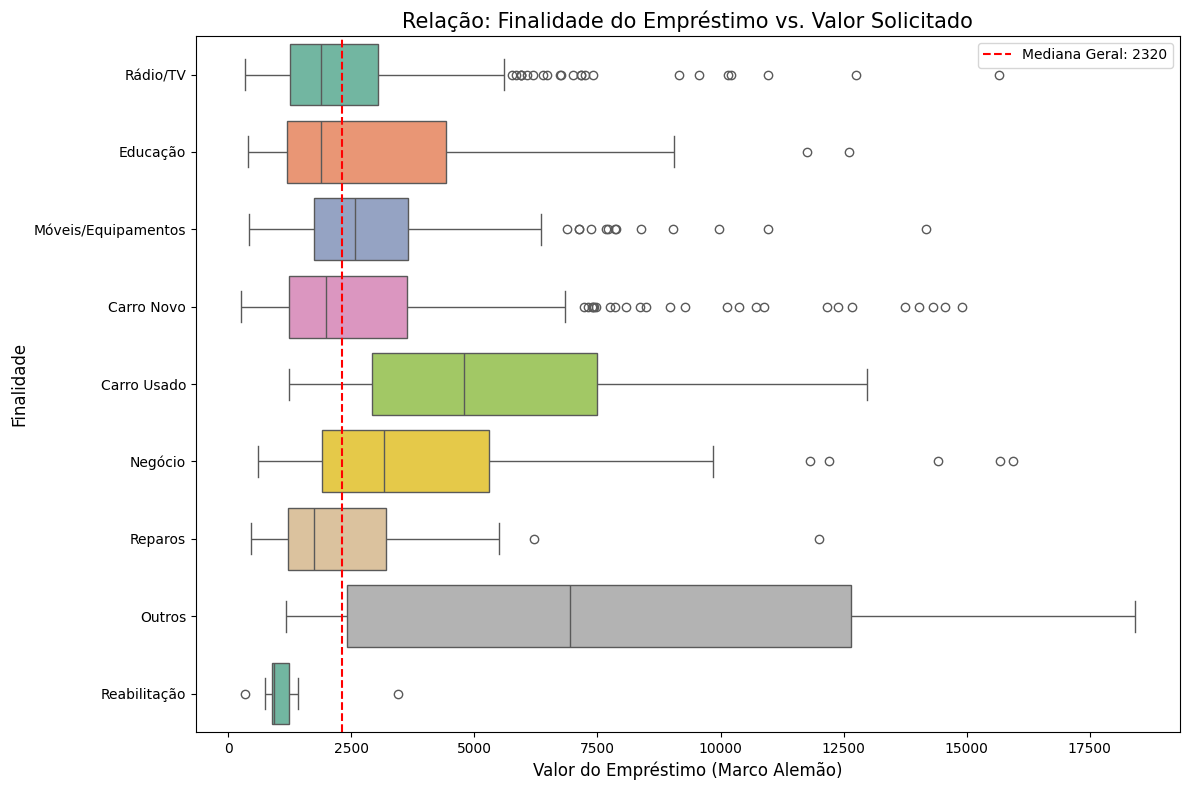

In [ ]:
# Configurando o tamanho da figura
plt.figure(figsize=(12, 8))

# Criando o boxplot: Eixo X = Valor, Eixo Y = Objetivo
sns.boxplot(data=df, x='valor_emprestimo', y='finalidade', palette='Set2')

# Configuração de títulos e rótulos
plt.title("Relação: Finalidade do Empréstimo vs. Valor Solicitado", fontsize=15)
plt.xlabel("Valor do Empréstimo (Marco Alemão)", fontsize=12)
plt.ylabel("Finalidade", fontsize=12)

# Linha vertical mostrando a mediana geral de todo o dataset (para comparação)
mediana_geral = df['valor_emprestimo'].median()
plt.axvline(mediana_geral, color='red', linestyle='--', label=f'Mediana Geral: {mediana_geral:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Definir o valor de cada variável/categoria
limites_por_finalidade = {
    'Rádio/TV': 3000,
    'Carro Novo': 15000,
    'Carro Usado': 10000,
    'Educação': 5000,
    'Negócio': 18000,
    'Móveis/Equipamentos': 7000
}

# Foi criada uma função para aplicar o filtro ou um loop/query
# Aqui foi mantida as linhas que estão abaixo do limite definido no dicionário

def filtrar_outliers_custom(row):
    limite = limites_por_finalidade.get(row['finalidade'], 10000)
    return row['valor_emprestimo'] <= limite

# Aplicando o filtro
df_pos_outliers = df[df.apply(filtrar_outliers_custom, axis=1)].copy()

# Verificando o resultado
print(f'Tamanho original: {len(df)}')
print(f'Tamanho após filtro por categoria: {len(df_pos_outliers)}')

# Visualizando os maiores valores por categoria para validar
display(df_pos_outliers.groupby('finalidade')['valor_emprestimo'].max().reset_index())

Tamanho original: 1000
Tamanho após filtro por categoria: 889


,finalidade,valor_emprestimo
0,Carro Novo,14896
1,Carro Usado,9629
2,Educação,4623
3,Móveis/Equipamentos,6872
4,Negócio,15945
5,Outros,7582
6,Reabilitação,3447
7,Reparos,6204
8,Rádio/TV,2991


/tmp/ipykernel_336/2909629473.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pos_outliers, x='valor_emprestimo', y='finalidade', palette='Set2')


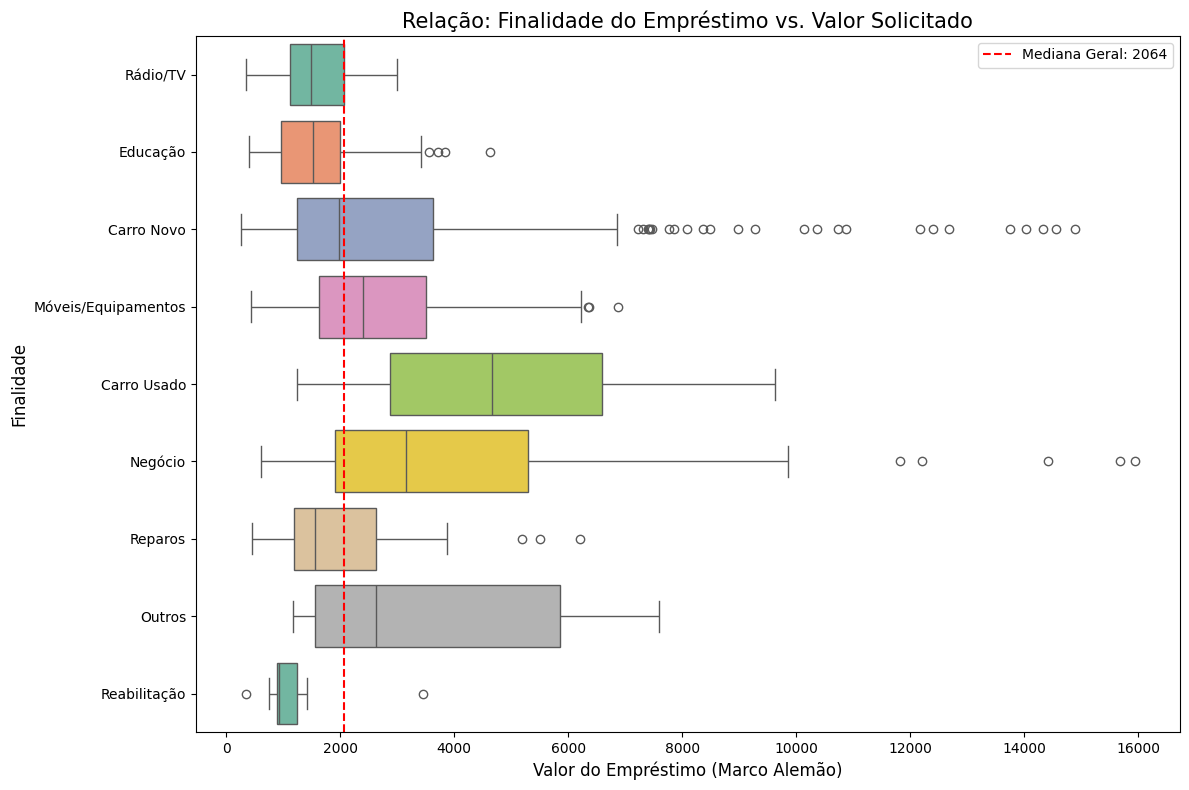

In [ ]:
# Configurando o tamanho da figura
plt.figure(figsize=(12, 8))

# Criando o boxplot: Eixo X = Valor, Eixo Y = Objetivo
sns.boxplot(data=df_pos_outliers, x='valor_emprestimo', y='finalidade', palette='Set2')

# Configuração de títulos e rótulos
plt.title("Relação: Finalidade do Empréstimo vs. Valor Solicitado", fontsize=15)
plt.xlabel("Valor do Empréstimo (Marco Alemão)", fontsize=12)
plt.ylabel("Finalidade", fontsize=12)

# Linha vertical mostrando a mediana geral de todo o dataset (para comparação)
mediana_geral = df_pos_outliers['valor_emprestimo'].median()
plt.axvline(mediana_geral, color='red', linestyle='--', label=f'Mediana Geral: {mediana_geral:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

Foram retiradas as colunas que não são úteis para a análise, realizado a limpeza de aspas nas células, tradução de colunas e seus respectivos valores (para que todos os leitores possam ler e entender os gráficos),remoção e ajuste manual de valores de outliers, e por fim ajustes nos valores númericos como nas colunas de status_poupança e status_conta.

In [ ]:
# Sobrescrevendo o df original com os dados limpos para os gráficos puxarem automaticamente
df = df_pos_outliers.copy()

## **4. Análise Exploratória**

### Distribuições

/tmp/ipykernel_336/850940932.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classificacao', palette=['#2ecc71', '#e74c3c'], ax=axes[2])


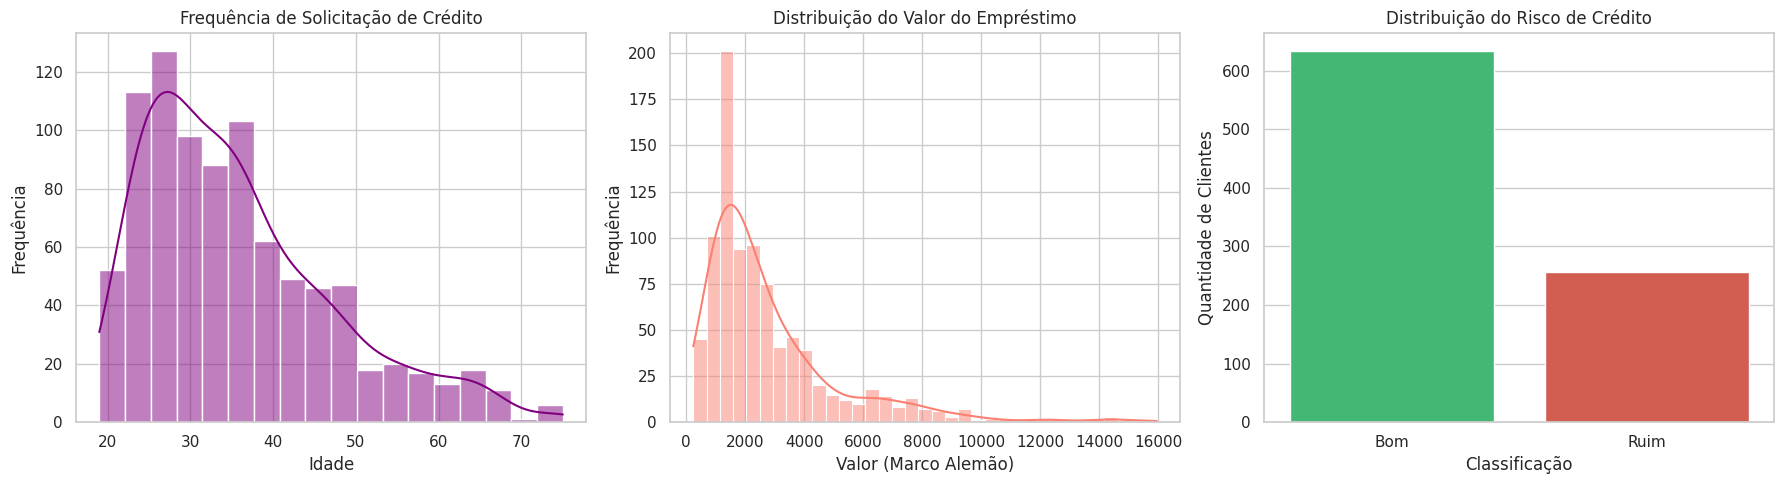

In [ ]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid", palette="muted")

# Criando uma figura grande com 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribuição da Idade (Histograma)
sns.histplot(data=df, x='idade_anos', kde=True, color='purple', ax=axes[0])
axes[0].set_title("Frequência de Solicitação de Crédito")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")

# Gráfico 2: Distribuição do Valor do Empréstimo (Histograma)
sns.histplot(data=df, x='valor_emprestimo', kde=True, color='salmon', ax=axes[1])
axes[1].set_title("Distribuição do Valor do Empréstimo")
axes[1].set_xlabel("Valor (Marco Alemão)")
axes[1].set_ylabel("Frequência")

# Gráfico 3: Distribuição da Variável Alvo (Gráfico de Barras)
sns.countplot(data=df, x='classificacao', palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title("Distribuição do Risco de Crédito")
axes[2].set_xlabel("Classificação")
axes[2].set_ylabel("Quantidade de Clientes")

plt.tight_layout()
plt.show()

### Geração de um histograma para visualizar os outliers e definir valores extremamente altos

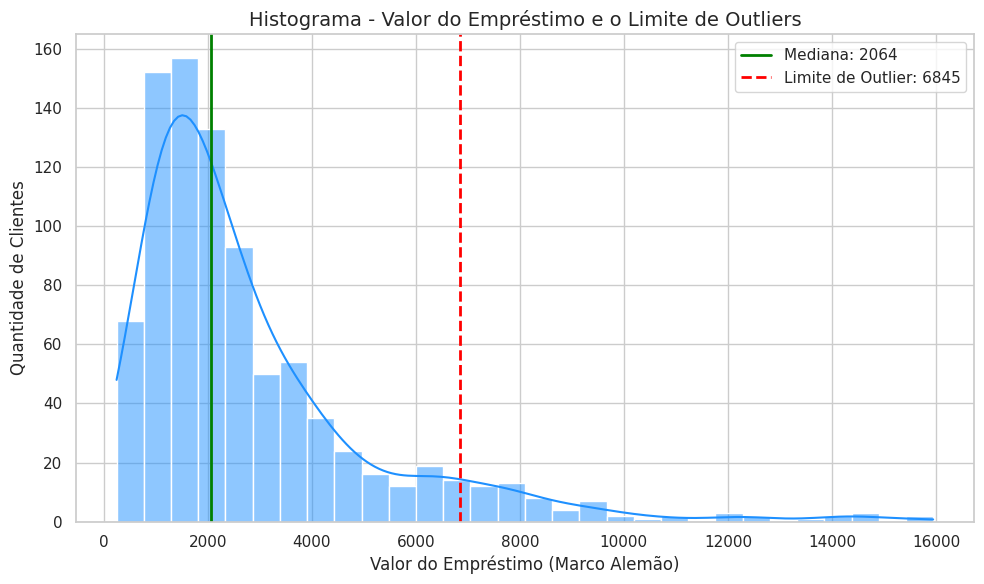

In [ ]:
# Calculando a matemática do Outlier (Método IQR)
Q1 = df['valor_emprestimo'].quantile(0.25)
Q3 = df['valor_emprestimo'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
mediana = df['valor_emprestimo'].median()

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Plotando o Histograma com a linha de densidade
sns.histplot(data=df, x='valor_emprestimo', bins=30, kde=True, color='dodgerblue')

# Desenhando as linhas para delimitar o que é outlier
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.0f}')
plt.axvline(limite_superior, color='red', linestyle='--', linewidth=2, label=f'Limite de Outlier: {limite_superior:.0f}')

plt.title("Histograma - Valor do Empréstimo e o Limite de Outliers", fontsize=14)
plt.xlabel("Valor do Empréstimo (Marco Alemão)", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

### Relações entre variáveis e padrões

### Correlações

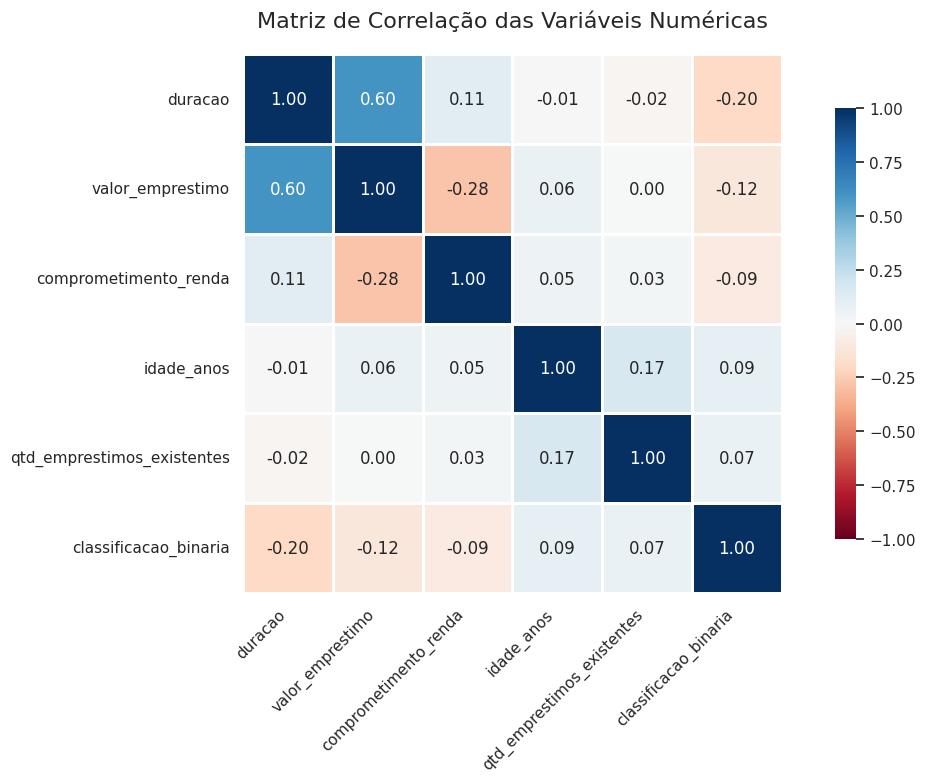

In [ ]:
# Seleção de colunas numéricas
colunas_numericas = [
    'duracao',
    'valor_emprestimo',
    'comprometimento_renda',
    'idade_anos',
    'qtd_emprestimos_existentes',
    'classificacao_binaria'
]

# Pegando apenas essas colunas do df
df_corr = df[colunas_numericas]

# Calculando a matriz de correlação
matriz_correlacao = df_corr.corr()


# 4. Configurando a figura
plt.figure(figsize=(12, 8))
sns.set_theme(style="darkgrid")

# 5. Plotando o Heatmap
sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### Gráfico de barras agrupadas para verificar se o histórico financeiro impacta na aprovação do crédito

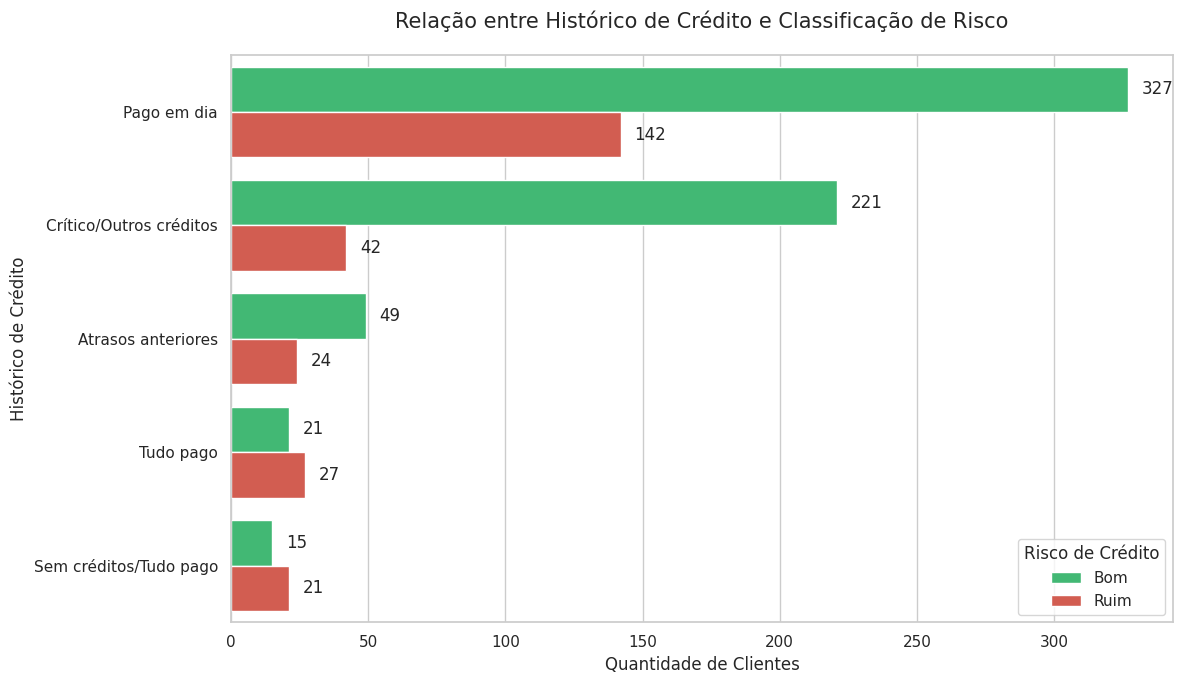

In [ ]:
# Definindo o tamanho e estilo
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras agrupadas
# Eixo Y: histórico_credito | Hue (cor): risco_credito
grafico = sns.countplot(
    data=df,
    y='historico_credito',
    hue='classificacao',
    palette=['#2ecc71', '#e74c3c'],
    order=df['historico_credito'].value_counts().index
)

# Ajustes de títulos e legendas
plt.title("Relação entre Histórico de Crédito e Classificação de Risco", fontsize=15, pad=20)
plt.xlabel("Quantidade de Clientes", fontsize=12)
plt.ylabel("Histórico de Crédito", fontsize=12)
plt.legend(title="Risco de Crédito", loc='lower right')

# Adicionando os valores nas barras para facilitar a leitura
for p in grafico.patches:
    width = p.get_width()
    if width > 0: # Apenas para barras com valor
        plt.text(width + 5, p.get_y() + p.get_height()/2, f'{int(width)}', va='center')

plt.tight_layout()
plt.show()

### Padrões e Tendências

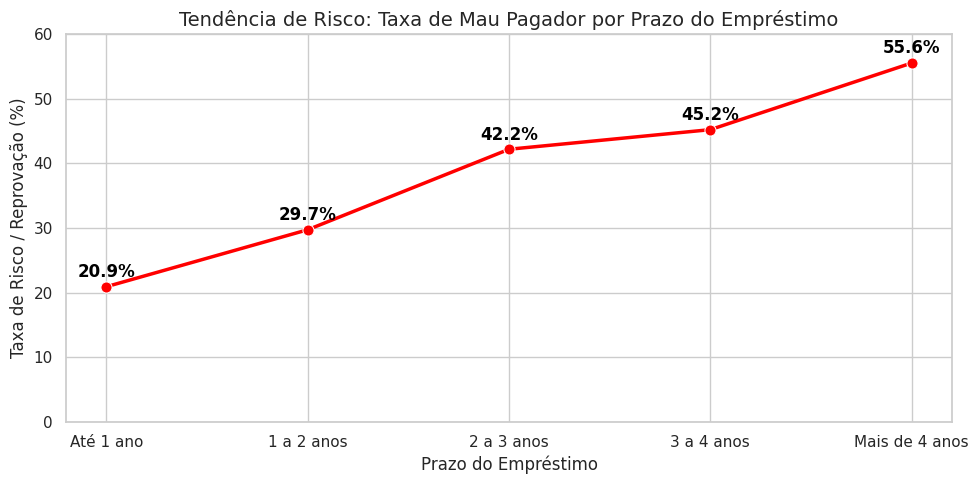

In [ ]:
# Faixas de tempo
faixas = [0, 12, 24, 36, 48, 100]
nomes_faixas = ['Até 1 ano', '1 a 2 anos', '2 a 3 anos', '3 a 4 anos', 'Mais de 4 anos']

df['faixa_duracao'] = pd.cut(df['duracao'], bins=faixas, labels=nomes_faixas)

# Agrupar pela nova coluna 'faixa_duracao' e calcular a % na 'classificacao_binaria'
tendencia_risco = df.groupby('faixa_duracao', observed=False)['classificacao_binaria'].apply(lambda x: (x == 0).mean() * 100).reset_index()
tendencia_risco.rename(columns={'classificacao_binaria': 'taxa_inadimplencia'}, inplace=True)

# Plotando o gráfico de tendência (Gráfico de Linha)
plt.figure(figsize=(10, 5))
sns.lineplot(data=tendencia_risco, x='faixa_duracao', y='taxa_inadimplencia', marker='o', color='red', linewidth=2.5, markersize=8)

plt.title("Tendência de Risco: Taxa de Mau Pagador por Prazo do Empréstimo", fontsize=14)
plt.xlabel("Prazo do Empréstimo", fontsize=12)
plt.ylabel("Taxa de Risco / Reprovação (%)", fontsize=12)

# Colocando os valores em cima dos pontos do gráfico
for x, y in zip(range(len(tendencia_risco)), tendencia_risco['taxa_inadimplencia']):
    plt.text(x, y + 1.5, f'{y:.1f}%', ha='center', color='black', weight='bold')

plt.ylim(0, 60)
plt.tight_layout()
plt.show()

# Limpando a coluna temporária para manter o dataset limpo
df.drop(columns=['faixa_duracao'], inplace=True)

### Pessoas mais jovens tendem a ter um risco maior de inadimplência do que pessoas mais velhas

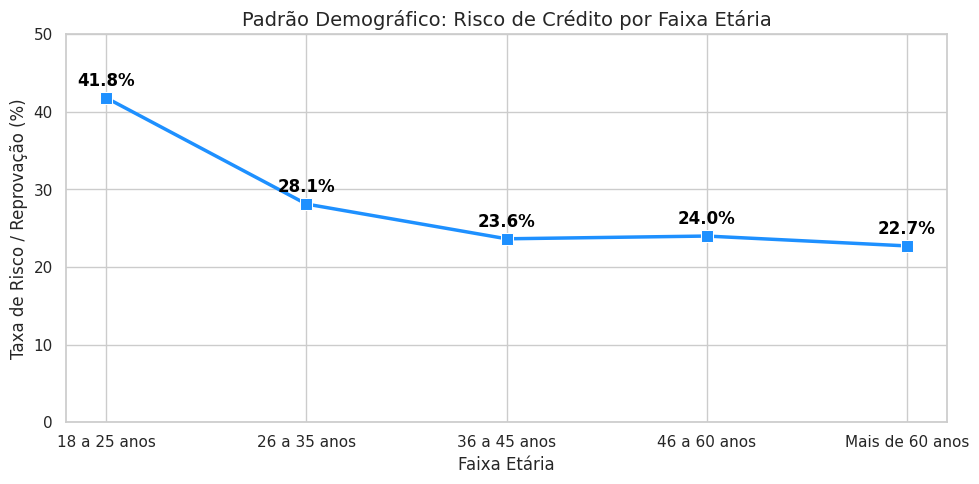

In [ ]:
# Criando as faixas etárias
faixas_idade = [18, 25, 35, 45, 60, 100]
nomes_faixas_idade = ['18 a 25 anos', '26 a 35 anos', '36 a 45 anos', '46 a 60 anos', 'Mais de 60 anos']

df['faixa_idade'] = pd.cut(df['idade_anos'], bins=faixas_idade, labels=nomes_faixas_idade)

# Agrupar pela nova coluna 'faixa_idade' e calcular a % na 'classificacao_binaria'
tendencia_idade = df.groupby('faixa_idade', observed=False)['classificacao_binaria'].apply(lambda x: (x == 0).mean() * 100).reset_index()
tendencia_idade.rename(columns={'classificacao_binaria': 'taxa_inadimplencia'}, inplace=True)

# Gerando o gráfico de tendência demográfica (Gráfico de Linha)
plt.figure(figsize=(10, 5))
# Usando a cor 'dodgerblue' (azul) para diferenciar do gráfico vermelho de prazo
sns.lineplot(data=tendencia_idade, x='faixa_idade', y='taxa_inadimplencia', marker='s', color='dodgerblue', linewidth=2.5, markersize=8)

plt.title("Padrão Demográfico: Risco de Crédito por Faixa Etária", fontsize=14)
plt.xlabel("Faixa Etária", fontsize=12)
plt.ylabel("Taxa de Risco / Reprovação (%)", fontsize=12)

# Colocando os valores em cima dos pontos quadrados do gráfico
for x, y in zip(range(len(tendencia_idade)), tendencia_idade['taxa_inadimplencia']):
    plt.text(x, y + 1.5, f'{y:.1f}%', ha='center', color='black', weight='bold')

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

# Limpando a coluna temporária para manter o dataset limpo
df.drop(columns=['faixa_idade'], inplace=True)

In [ ]:
# Criando o perfil do dataset
profile = ProfileReport(df, title="Relatório EDA - Crédito")

# Para visualizar o relatório dentro do próprio notebook do Colab
profile.to_notebook_iframe()

# Para salvar como um arquivo HTML e baixar no computador
profile.to_file("relatorio_eda_credit.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 38.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 5. Interpretação dos Resultados

> Nesta etapa, os achados visuais da análise exploratória são consolidados para responder à pergunta orientadora do projeto e delinear o perfil de risco da instituição financeira.

## Resposta à pergunta orientadora:

  "O histórico financeiro impacta a aprovação do crédito?". A resposta extraída dos dados é **sim**, o impacto é significativo, porém contra-intuitivo.
A análise bivariada demonstrou que a ausência de histórico ("Sem créditos/Tudo pago") é punida pelo modelo de aprovação do banco com uma taxa de rejeição proporcionalmente mais alta.

  Em contrapartida, clientes com um histórico classificado como "Crítico/Outros créditos" representam o maior volume absoluto de bons pagadores aprovados. Interpreta-se que, para a política de crédito desta instituição, possuir um histórico longo e ativo no mercado (mesmo com ressalvas) gera mais previsibilidade do que a completa ausência de informações financeiras prévias. O "cliente desconhecido" é o maior risco.

# O Perfil do Risco (Padrões Identificados):

> Além do histórico, a análise de tendências revelou que o risco de crédito na base estudada é fortemente moldado por duas alavancas principais:

* Prazo: O risco possui uma relação linear positiva com a duração do empréstimo.  Contratos de curto prazo (até 1 ano) giram em torno de 20% de risco, enquanto financiamentos longos (acima de 4 anos) ultrapassam a marca crítica de 50% de inadimplência.

* Demografia (Idade): O risco possui uma relação decrescente com a idade. Jovens entre 18 e 25 anos concentram as maiores taxas de reprovação/calote, enquanto o risco cai progressivamente à medida que o cliente envelhece, refletindo a busca do banco por perfis com maior maturidade e estabilidade financeira.

# 6. Conclusões

* **Síntese do Estudo:**
O presente projeto cumpriu o objetivo de aplicar o ciclo completo de Análise de Dados sobre a base German Credit Data. Através de etapas rigorosas de limpeza, tratamento de valores ausentes, clipagem de outliers extremos (apenas quando matematicamente e em regras de negócios não faziam sentido) e análise exploratória visual, foi possível decifrar o comportamento de aprovação e risco da instituição. Fica evidente que a modelagem de crédito vai muito além do valor em conta, dependendo fundamentalmente do tempo de relacionamento com o mercado (histórico), idade do solicitante e prazo de exposição do capital.

* **Limitações e Viés Histórico dos Dados:**
Uma limitação crítica identificada durante a fase de compreensão e preparação dos dados reside no viés social e histórico embutido na coleta (Alemanha, década de 1970). Na variável de perfil pessoal (perfil_pessoal), notou-se que o estado civil masculino é detalhado em múltiplas categorias para análise minuciosa de risco, enquanto o perfil feminino agrupa mulheres casadas, separadas e divorciadas em um único bloco, sem granularidade. Essa limitação estrutural impede uma análise de risco de crédito justa e equilibrada do ponto de vista de gênero para aplicações modernas, exigindo cautela caso esta base fosse utilizada para treinar algoritmos de Machine Learning nos dias atuais.